In [ ]:
import os
import sys
import torch

if not os.path.exists('/content/PIDNet'):
    print("Cloning PIDNet...")
    !git clone -q https://github.com/xujiacong/PIDNet.git

!pip install -q yacs timm tensorboardX

repo_path = '/content/PIDNet'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
os.chdir(repo_path)

print(f"✅ Environment ready. CWD: {os.getcwd()}")

Cloning PIDNet...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.2 MB/s eta 0:00:00
✅ Environment ready. CWD: /content/PIDNet


In [3]:
import os

pidnet_root = '/content/PIDNet'

patches = {
    'datasets/base_dataset.py': [
        ('np.int(', 'int('),
        ('dtype=np.int)', 'dtype=int)'),
        ('dtype=np.int,', 'dtype=int,'),
    ],
    'datasets/cityscapes.py': [
        ('np.int(', 'int('),
        ('dtype=np.int)', 'dtype=int)'),
        ('dtype=np.int,', 'dtype=int,'),
    ],
    'utils/utils.py': [
        ('np.int(', 'int('),
        ('dtype=np.int)', 'dtype=int)'),
        ('dtype=np.int,', 'dtype=int,'),
    ],
    'utils/criterion.py': [
        ('weight=weight,', 'weight=None,'),
    ],
}

for rel_path, replacements in patches.items():
    fpath = os.path.join(pidnet_root, rel_path)
    if not os.path.exists(fpath):
        print(f"⚠️  Not found: {fpath}")
        continue
    with open(fpath, 'r') as f:
        src = f.read()
    changed = False
    for old, new in replacements:
        if old in src:
            src = src.replace(old, new)
            print(f"✅ Patched '{old}' in {rel_path}")
            changed = True
        else:
            print(f"   Already clean: '{old}' in {rel_path}")
    if changed:
        with open(fpath, 'w') as f:
            f.write(src)

print("\n✅ All patches applied.")

✅ Patched 'np.int(' in datasets/base_dataset.py
   Already clean: 'dtype=np.int)' in datasets/base_dataset.py
   Already clean: 'dtype=np.int,' in datasets/base_dataset.py
   Already clean: 'np.int(' in datasets/cityscapes.py
   Already clean: 'dtype=np.int)' in datasets/cityscapes.py
   Already clean: 'dtype=np.int,' in datasets/cityscapes.py
   Already clean: 'np.int(' in utils/utils.py
✅ Patched 'dtype=np.int)' in utils/utils.py
   Already clean: 'dtype=np.int,' in utils/utils.py
✅ Patched 'weight=weight,' in utils/criterion.py

✅ All patches applied.


In [ ]:
!pip install tensorboardX

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.0 MB/s eta 0:00:00


In [ ]:
import os

dataset_root = '/content/drive/MyDrive/AIFR/Project/Dataset'


img_dir = os.path.join(dataset_root, 'cityscapes', 'Images')
mask_dir = os.path.join(dataset_root, 'cityscapes', 'Masks')

if not os.path.exists(img_dir):
    print(f"❌ Images folder not found at: {img_dir}")
    print("Check your Drive structure.")
else:
    files = sorted([os.path.splitext(f)[0] for f in os.listdir(img_dir) if f.endswith('.jpg')])
    print(f"Found {len(files)} images.")


    entries = [f"Images/{f}.jpg Masks/{f}.png" for f in files]

    split = int(len(entries) * 0.9)
    train_entries = entries[:split]
    val_entries = entries[split:]

    with open(os.path.join(dataset_root, 'train.txt'), 'w') as f:
        f.write('\n'.join(train_entries))
    with open(os.path.join(dataset_root, 'val.txt'), 'w') as f:
        f.write('\n'.join(val_entries))

    print(f"✅ train.txt: {len(train_entries)} images")
    print(f"✅ val.txt:   {len(val_entries)} images")
    print(f"\nSample line: {entries[0]}")

Found 59 images.
✅ train.txt: 53 images
✅ val.txt:   6 images

Sample line: Images/frame_100_jpg.rf.11aacf9ae7ce8d9d9695c853a5224e5c.jpg Masks/frame_100_jpg.rf.11aacf9ae7ce8d9d9695c853a5224e5c.png


In [5]:
import os

pidnet_root = '/content/PIDNet'

patches = {
    'datasets/base_dataset.py': [
        ('np.int(', 'int('),
        ('dtype=np.int)', 'dtype=int)'),
        ('dtype=np.int,', 'dtype=int,'),
    ],
    'datasets/cityscapes.py': [
        ('np.int(', 'int('),
        ('dtype=np.int)', 'dtype=int)'),
        ('dtype=np.int,', 'dtype=int,'),
    ],
    'utils/utils.py': [
        ('np.int(', 'int('),
        ('dtype=np.int)', 'dtype=int)'),
        ('dtype=np.int,', 'dtype=int,'),
    ],
    'utils/criterion.py': [
        ('weight=weight,', 'weight=None,'),
    ],
}

for rel_path, replacements in patches.items():
    fpath = os.path.join(pidnet_root, rel_path)
    if not os.path.exists(fpath):
        print(f"⚠️  Not found: {fpath}")
        continue
    with open(fpath, 'r') as f:
        src = f.read()
    changed = False
    for old, new in replacements:
        if old in src:
            src = src.replace(old, new)
            print(f"✅ Patched '{old}' in {rel_path}")
            changed = True
        else:
            print(f"   Already clean: '{old}' in {rel_path}")
    if changed:
        with open(fpath, 'w') as f:
            f.write(src)

print("\n✅ All patches applied.")

   Already clean: 'np.int(' in datasets/base_dataset.py
   Already clean: 'dtype=np.int)' in datasets/base_dataset.py
   Already clean: 'dtype=np.int,' in datasets/base_dataset.py
   Already clean: 'np.int(' in datasets/cityscapes.py
   Already clean: 'dtype=np.int)' in datasets/cityscapes.py
   Already clean: 'dtype=np.int,' in datasets/cityscapes.py
   Already clean: 'np.int(' in utils/utils.py
   Already clean: 'dtype=np.int)' in utils/utils.py
   Already clean: 'dtype=np.int,' in utils/utils.py
   Already clean: 'weight=weight,' in utils/criterion.py

✅ All patches applied.


In [ ]:
import os

pidnet_root = '/content/PIDNet'

patches = {
    'datasets/base_dataset.py': [
        ('np.int(', 'int('),
        ('dtype=np.int)', 'dtype=int)'),
        ('dtype=np.int,', 'dtype=int,'),
    ],
    'datasets/cityscapes.py': [
        ('np.int(', 'int('),
        ('dtype=np.int)', 'dtype=int)'),
        ('dtype=np.int,', 'dtype=int,'),
    ],
    'utils/utils.py': [
        ('np.int(', 'int('),
        ('dtype=np.int)', 'dtype=int)'),
        ('dtype=np.int,', 'dtype=int,'),
    ],
    'utils/criterion.py': [
        ('weight=weight,', 'weight=None,'),
    ],
}

for rel_path, replacements in patches.items():
    fpath = os.path.join(pidnet_root, rel_path)
    if not os.path.exists(fpath):
        print(f"⚠️  Not found: {fpath}")
        continue
    with open(fpath, 'r') as f:
        src = f.read()
    changed = False
    for old, new in replacements:
        if old in src:
            src = src.replace(old, new)
            print(f"✅ Patched '{old}' in {rel_path}")
            changed = True
        else:
            print(f"   Already clean: '{old}' in {rel_path}")
    if changed:
        with open(fpath, 'w') as f:
            f.write(src)

utils_path = os.path.join(pidnet_root, 'utils/utils.py')
with open(utils_path, 'r') as f:
    src = f.read()

old = 'loss_sb = self.sem_loss(outputs[-2], bd_label)'
new = 'loss_sb = self.sem_loss([outputs[-2]], bd_label)'

if old in src:
    src = src.replace(old, new)
    with open(utils_path, 'w') as f:
        f.write(src)
    print("✅ utils.py: loss_sb wrapped in list")
else:
    print("   utils.py: loss_sb already patched or not found")

print("\n✅ All patches applied.")

   Already clean: 'np.int(' in datasets/base_dataset.py
   Already clean: 'dtype=np.int)' in datasets/base_dataset.py
   Already clean: 'dtype=np.int,' in datasets/base_dataset.py
   Already clean: 'np.int(' in datasets/cityscapes.py
   Already clean: 'dtype=np.int)' in datasets/cityscapes.py
   Already clean: 'dtype=np.int,' in datasets/cityscapes.py
   Already clean: 'np.int(' in utils/utils.py
   Already clean: 'dtype=np.int)' in utils/utils.py
   Already clean: 'dtype=np.int,' in utils/utils.py
   Already clean: 'weight=weight,' in utils/criterion.py
✅ utils.py: loss_sb wrapped in list

✅ All patches applied.


In [ ]:
import re

train_path = '/content/PIDNet/tools/train.py'
with open(train_path, 'r') as f:
    src = f.read()

strip_code = '''
    # ── Strip 19-class head, reinit for NUM_CLASSES ──────────────────────────
    import torch.nn as nn
    num_classes = config.DATASET.NUM_CLASSES
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) and module.out_channels == 19:
            parent_name = '.'.join(name.split('.')[:-1])
            child_name  = name.split('.')[-1]
            parent = model
            for part in parent_name.split('.'):
                if part:
                    parent = getattr(parent, part)
            new_conv = nn.Conv2d(
                module.in_channels, num_classes,
                kernel_size=module.kernel_size,
                stride=module.stride,
                padding=module.padding,
                bias=(module.bias is not None)
            )
            nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')
            if new_conv.bias is not None:
                nn.init.constant_(new_conv.bias, 0)
            setattr(parent, child_name, new_conv)
    print(f"✅ Head replaced: all 19-class convs → {num_classes}-class convs")
    model = model.cuda()
    # ─────────────────────────────────────────────────────────────────────────
'''

target = 'model = models.pidnet.get_seg_model(config, imgnet_pretrained=imgnet)'
if target in src:
    src = src.replace(target, target + strip_code)
    with open(train_path, 'w') as f:
        f.write(src)
    print("✅ train.py patched: head stripping added")
else:
    print("⚠️  Target line not found — printing nearby lines for inspection:")
    for i, line in enumerate(src.splitlines()):
        if 'get_seg_model' in line or 'get_pred_model' in line:
            print(f"  {i}: {line}")

✅ train.py patched: head stripping added


In [ ]:
import os
import numpy as np
from PIL import Image

mask_dir = '/content/drive/MyDrive/AIFR/Project/Dataset/cityscapes/Masks'

files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])
print(f"Found {len(files)} masks\n")

all_values = set()
problems = []

for fname in files:
    mask = np.array(Image.open(os.path.join(mask_dir, fname)))
    unique = np.unique(mask)
    all_values.update(unique.tolist())

    bad = [v for v in unique if v not in range(6) and v != 255]
    if bad:
        problems.append((fname, unique.tolist()))

print(f"All unique pixel values across ALL masks: {sorted(all_values)}")
print(f"\nMasks with unexpected values: {len(problems)}")
for fname, vals in problems[:5]:
    print(f"  {fname}: {vals}")

Found 59 masks

All unique pixel values across ALL masks: [0, 1, 2, 3, 4, 5]

Masks with unexpected values: 0


In [ ]:
import sys
import torch
import os
import numpy as np
from PIL import Image
import cv2

sys.path.insert(0, '/content/PIDNet')
os.chdir('/content/PIDNet')

from configs.default import _C as config
from configs.default import update_config
from models.pidnet import get_seg_model
import torch.nn as nn

device = torch.device('cuda')

# 1. Load config
class Args:
    def __init__(self, cfg):
        self.cfg = cfg
        self.opts = []

update_config(config, Args('configs/cityscapes/pidnet_large_cityscapes.yaml'))
config.defrost()
config.DATASET.NUM_CLASSES = 6
config.MODEL.PRETRAINED = '/content/drive/MyDrive/AIFR/Project/PIDNet_L_Cityscapes_val.pt'
config.freeze()

model = get_seg_model(config, imgnet_pretrained=False)
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d) and module.out_channels == 19:
        parent_name = '.'.join(name.split('.')[:-1])
        child_name  = name.split('.')[-1]
        parent = model
        for part in parent_name.split('.'):
            if part:
                parent = getattr(parent, part)
        new_conv = nn.Conv2d(module.in_channels, 6,
                             kernel_size=module.kernel_size,
                             stride=module.stride,
                             padding=module.padding,
                             bias=(module.bias is not None))
        nn.init.kaiming_normal_(new_conv.weight)
        if new_conv.bias is not None:
            nn.init.constant_(new_conv.bias, 0)
        setattr(parent, child_name, new_conv)

model = model.cuda().eval()

img_folder = '/content/drive/MyDrive/AIFR/Project/Dataset/cityscapes/Images/'
msk_folder = '/content/drive/MyDrive/AIFR/Project/Dataset/cityscapes/Masks/'

try:
    sample_img_name = sorted([f for f in os.listdir(img_folder) if f.endswith('.jpg')])[0]
    sample_msk_name = sample_img_name.replace('.jpg', '_mask.png')

    img_path = os.path.join(img_folder, sample_img_name)
    mask_path = os.path.join(msk_folder, sample_msk_name)
    print(f"Loading hashed pair: {sample_img_name} <--> {sample_msk_name}")
except IndexError:
    print(" Error: No .jpg files found in Images folder. Check your Drive mount.")
    sys.exit()

img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (1024, 1024))
img_tensor = torch.from_numpy(img).permute(2,0,1).float() / 255.0

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
img_tensor = (img_tensor - mean) / std
img_tensor = img_tensor.unsqueeze(0).cuda()


mask = np.array(Image.open(mask_path).resize((1024, 1024), Image.NEAREST))
label = torch.from_numpy(mask).long().unsqueeze(0).cuda()

print(f"Image tensor — min: {img_tensor.min():.3f}, max: {img_tensor.max():.3f}")
print(f"Label — unique values: {label.unique().tolist()}")


with torch.no_grad():
    outputs = model(img_tensor)

print(f"\nNumber of outputs: {len(outputs)}")
for i, o in enumerate(outputs):
    print(f"  Output[{i}] shape: {o.shape}, min: {o.min():.3f}, max: {o.max():.3f}")

import torch.nn.functional as F
out = F.interpolate(outputs[0], size=(1024,1024), mode='bilinear', align_corners=True)
loss = F.cross_entropy(out, label, ignore_index=255)
print(f"\nDirect cross_entropy loss: {loss.item():.4f}")

✅ Loading hashed pair: frame_100_jpg.rf.11aacf9ae7ce8d9d9695c853a5224e5c.jpg <--> frame_100_jpg.rf.11aacf9ae7ce8d9d9695c853a5224e5c_mask.png
Image tensor — min: -1.998, max: 2.640
Label — unique values: [0, 1, 3, 4, 5]

Number of outputs: 3
  Output[0] shape: torch.Size([1, 6, 128, 128]), min: -9.513, max: 10.842
  Output[1] shape: torch.Size([1, 6, 128, 128]), min: -20.246, max: 17.103
  Output[2] shape: torch.Size([1, 1, 128, 128]), min: -11.421, max: 5.628

Direct cross_entropy loss: 3.2613


In [ ]:
train_path = '/content/PIDNet/tools/train.py'
with open(train_path, 'r') as f:
    src = f.read()

bn_reset_code = '''
    # ── Reset BatchNorm running stats so they recalibrate on new data ─────────
    import torch.nn as nn
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
            m.reset_running_stats()
            m.momentum = 0.01  # slower momentum = more stable warmup
    print("✅ BatchNorm running stats reset")
    # ──────────────────────────────────────────────────────────────────────────
'''

target = 'print(f"✅ Head replaced: all 19-class convs → {num_classes}-class convs")'
if target in src:
    src = src.replace(target, target + bn_reset_code)
    with open(train_path, 'w') as f:
        f.write(src)
    print("✅ train.py: BN reset added")
else:
    print("⚠️ Target not found — check if train.py was already patched")

✅ train.py: BN reset added


In [ ]:
import os

dataset_root = '/content/drive/MyDrive/AIFR/Project/Dataset/cityscapes'
images_dir = os.path.join(dataset_root, 'Images')
masks_dir = os.path.join(dataset_root, 'Masks')


image_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.jpg')])

manifest_entries = []
for img_name in image_files:
    
    mask_name = img_name.replace('.jpg', '_mask.png')

    if os.path.exists(os.path.join(masks_dir, mask_name)):
        manifest_entries.append(f"Images/{img_name} Masks/{mask_name}")
    else:
        print(f"⚠️ Warning: Missing mask for {img_name}")


split_idx = int(len(manifest_entries) * 0.9)
train_path = '/content/drive/MyDrive/AIFR/Project/Dataset/train.txt'
val_path = '/content/drive/MyDrive/AIFR/Project/Dataset/val.txt'

with open(train_path, 'w') as f:
    f.write('\n'.join(manifest_entries[:split_idx]))
with open(val_path, 'w') as f:
    f.write('\n'.join(manifest_entries[split_idx:]))

print(f"✅ Manifests updated. Total pairs: {len(manifest_entries)}")

✅ Manifests updated. Total pairs: 59


In [ ]:
import os, sys, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import cv2
from PIL import Image

sys.path.insert(0, '/content/PIDNet')
os.chdir('/content/PIDNet')


DATASET_ROOT = '/content/drive/MyDrive/AIFR/Project/Dataset/cityscapes'
TRAIN_TXT    = '/content/drive/MyDrive/AIFR/Project/Dataset/train.txt'
VAL_TXT      = '/content/drive/MyDrive/AIFR/Project/Dataset/val.txt'
WEIGHTS_PATH = '/content/drive/MyDrive/AIFR/Project/PIDNet_L_Cityscapes_val.pt'
SAVE_PATH    = '/content/drive/MyDrive/AIFR/Project/pidnet_finetuned.pt'
NUM_CLASSES  = 6
IMG_SIZE     = 512
BATCH_SIZE   = 2
NUM_EPOCHS   = 100
LR           = 1e-4
IGNORE_LABEL = 255
DEVICE       = torch.device('cuda')

class SegDataset(Dataset):
    def __init__(self, txt_file, root, img_size, augment=True):
        self.root     = root
        self.img_size = img_size
        self.augment  = augment
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

        with open(txt_file) as f:
            lines = [l.strip() for l in f if l.strip()]

        self.pairs = []
        for line in lines:
            parts = line.split()
            self.pairs.append((
                os.path.join(root, parts[0]),
                os.path.join(root, parts[1])
            ))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = np.array(Image.open(mask_path))

        img  = cv2.resize(img,  (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        if self.augment:
            if np.random.rand() > 0.5:
                img  = np.fliplr(img).copy()
                mask = np.fliplr(mask).copy()
            if np.random.rand() > 0.5:
                img = np.clip(img * np.random.uniform(0.8, 1.2), 0, 255).astype(np.uint8)

        img  = img.astype(np.float32) / 255.0
        img  = (img - self.mean) / self.std
        img  = torch.from_numpy(img).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()
        return img, mask

train_ds     = SegDataset(TRAIN_TXT, DATASET_ROOT, IMG_SIZE, augment=True)
val_ds       = SegDataset(VAL_TXT,   DATASET_ROOT, IMG_SIZE, augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=1,          shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

imgs, masks = next(iter(train_loader))
print(f"Image shape: {imgs.shape}, dtype: {imgs.dtype}")
print(f"Mask shape:  {masks.shape}, dtype: {masks.dtype}")
print(f"Mask unique values: {masks.unique().tolist()}")
print(f"Image nan: {torch.isnan(imgs).any()}")

from models.pidnet import get_pred_model

model = get_pred_model('pidnet_l', 19)

ckpt  = torch.load(WEIGHTS_PATH, map_location='cpu')
state = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt
state = {k.replace('model.', ''): v for k, v in state.items()}
missing, unexpected = model.load_state_dict(state, strict=False)
print(f"\n✅ Pretrained weights loaded cleanly")
print(f"   Missing:    {missing}")
print(f"   Unexpected: {unexpected}")


print("\nLayers outputting 19 classes (will be replaced):")
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d) and module.out_channels == 19:
        print(f"  {name}: {module.in_channels} → {module.out_channels}")

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d) and module.out_channels == 19:
        parent = model
        parts  = name.split('.')
        for part in parts[:-1]:
            parent = getattr(parent, part)
        new_conv = nn.Conv2d(
            module.in_channels, NUM_CLASSES,
            kernel_size=module.kernel_size,
            stride=module.stride,
            padding=module.padding,
            bias=(module.bias is not None)
        )
        nn.init.kaiming_normal_(new_conv.weight, mode='fan_out', nonlinearity='relu')
        if new_conv.bias is not None:
            nn.init.constant_(new_conv.bias, 0)
        setattr(parent, parts[-1], new_conv)

print(f"\n✅ Final layers replaced: 19 → {NUM_CLASSES} classes")

remaining = [n for n, m in model.named_modules()
             if isinstance(m, nn.Conv2d) and m.out_channels == 19]
print(f"   Remaining 19-class layers: {remaining}  (should be empty)")

model = model.to(DEVICE)

model.eval()
with torch.no_grad():
    test_out = model(imgs[:1].to(DEVICE))
    if isinstance(test_out, (list, tuple)):
        test_out = test_out[0]
    print(f"\n✅ Test forward pass — output shape: {test_out.shape}")
    print(f"   Has nan: {torch.isnan(test_out).any()}")
    print(f"   Min: {test_out.min():.3f}, Max: {test_out.max():.3f}")

class_weights = torch.tensor([0.5, 2.0, 2.0, 0.5, 1.0, 8.0]).to(DEVICE)
criterion     = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_LABEL)
optimizer     = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

CLASS_NAMES = ['Background', 'Human', 'Obstacle', 'Road', 'Sidewalk', 'SpeedBreaker']

def compute_miou(preds, labels, num_classes, ignore=255):
    ious = []
    p = preds.cpu().numpy().flatten()
    l = labels.cpu().numpy().flatten()
    mask = l != ignore
    p, l = p[mask], l[mask]
    for c in range(num_classes):
        tp = ((p == c) & (l == c)).sum()
        fp = ((p == c) & (l != c)).sum()
        fn = ((p != c) & (l == c)).sum()
        if tp + fp + fn == 0:
            continue
        ious.append((c, tp / (tp + fp + fn)))
    return ious

best_miou = 0.0
model.train()

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss  = 0.0
    nan_batches = 0

    for imgs, masks in train_loader:
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        out = model(imgs)

        if isinstance(out, (list, tuple)):
            out = out[0]

        if out.shape[-2:] != masks.shape[-2:]:
            out = F.interpolate(out, size=masks.shape[-2:],
                                mode='bilinear', align_corners=True)

        loss = criterion(out, masks)

        if torch.isnan(loss):
            nan_batches += 1
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / max(len(train_loader) - nan_batches, 1)

    
    model.eval()
    all_ious = {c: [] for c in range(NUM_CLASSES)}

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE)
            out  = model(imgs)
            if isinstance(out, (list, tuple)):
                out = out[0]
            if out.shape[-2:] != masks.shape[-2:]:
                out = F.interpolate(out, size=masks.shape[-2:],
                                    mode='bilinear', align_corners=True)
            preds = out.argmax(dim=1).cpu()
            for c, iou in compute_miou(preds, masks, NUM_CLASSES):
                all_ious[c].append(iou)

    per_class = {c: np.mean(v) for c, v in all_ious.items() if v}
    mean_miou = np.mean(list(per_class.values())) if per_class else 0.0

    print(f"\nEpoch [{epoch+1:3d}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}  mIoU: {mean_miou:.4f}  LR: {scheduler.get_last_lr()[0]:.2e}  NaN batches: {nan_batches}")
    for c, iou in per_class.items():
        print(f"  {CLASS_NAMES[c]:12s}: {iou:.4f}")

    if mean_miou > best_miou:
        best_miou = mean_miou
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  ✅ Best model saved (mIoU={best_miou:.4f})")

print(f"\n🏁 Done. Best mIoU: {best_miou:.4f} → {SAVE_PATH}")

Train: 63 | Val: 8
Image shape: torch.Size([2, 3, 512, 512]), dtype: torch.float32
Mask shape:  torch.Size([2, 512, 512]), dtype: torch.int64
Mask unique values: [0, 1, 2, 3, 4, 5]
Image nan: False

✅ Pretrained weights loaded cleanly
   Missing:    []
   Unexpected: ['seghead_p.bn1.weight', 'seghead_p.bn1.bias', 'seghead_p.bn1.running_mean', 'seghead_p.bn1.running_var', 'seghead_p.bn1.num_batches_tracked', 'seghead_p.conv1.weight', 'seghead_p.bn2.weight', 'seghead_p.bn2.bias', 'seghead_p.bn2.running_mean', 'seghead_p.bn2.running_var', 'seghead_p.bn2.num_batches_tracked', 'seghead_p.conv2.weight', 'seghead_p.conv2.bias', 'seghead_d.bn1.weight', 'seghead_d.bn1.bias', 'seghead_d.bn1.running_mean', 'seghead_d.bn1.running_var', 'seghead_d.bn1.num_batches_tracked', 'seghead_d.conv1.weight', 'seghead_d.bn2.weight', 'seghead_d.bn2.bias', 'seghead_d.bn2.running_mean', 'seghead_d.bn2.running_var', 'seghead_d.bn2.num_batches_tracked', 'seghead_d.conv2.weight', 'seghead_d.conv2.bias', 'sem_loss.c

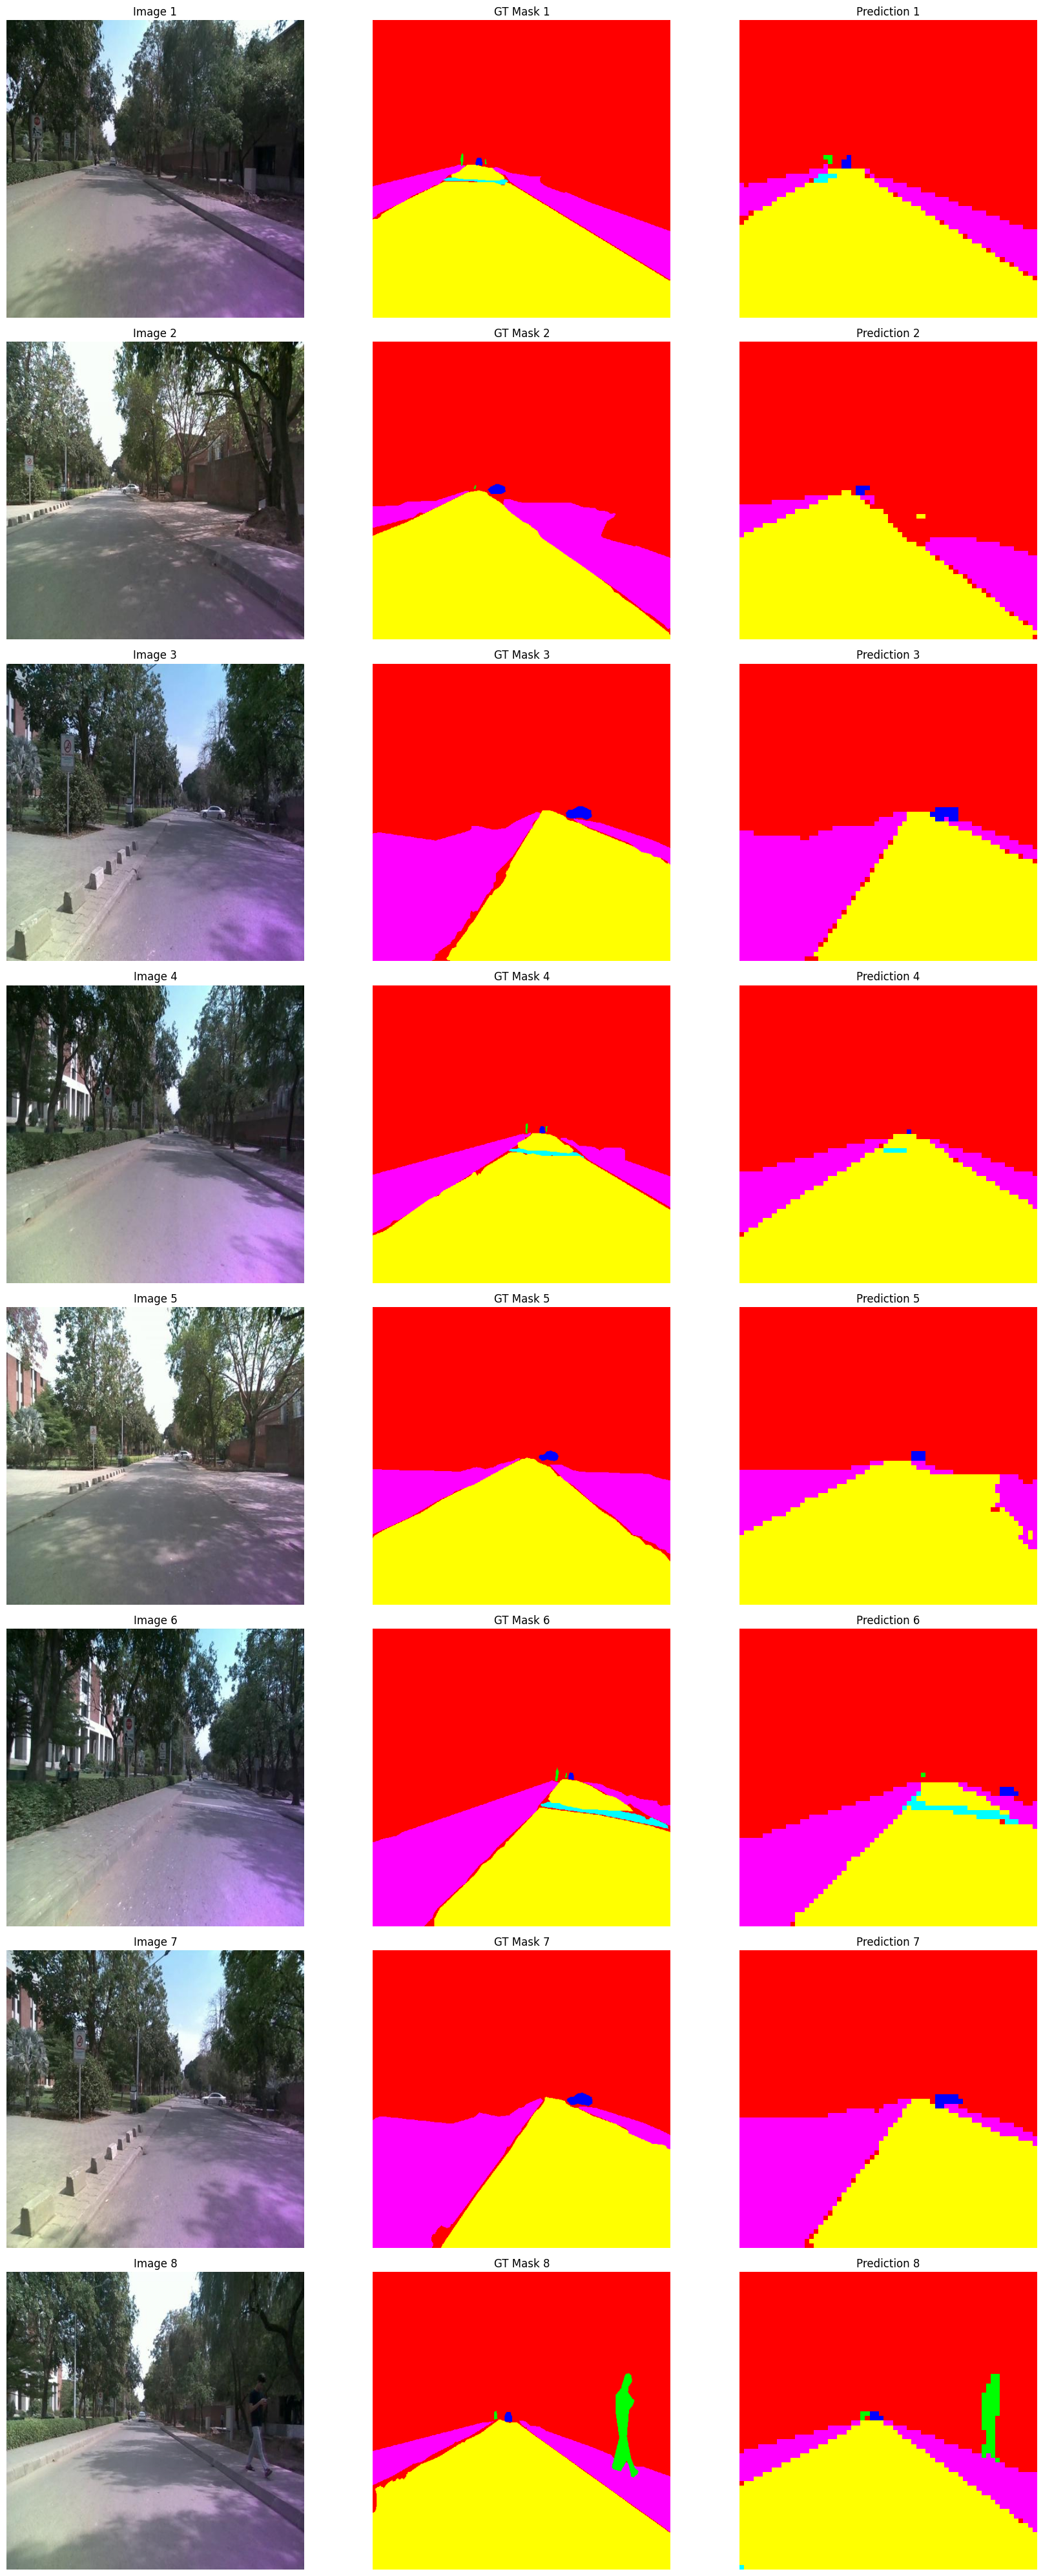

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from models.pidnet import get_pred_model

device = torch.device('cuda')
model_path = '/content/drive/MyDrive/AIFR/Project/pidnet_finetuned.pt'
val_txt = '/content/drive/MyDrive/AIFR/Project/Dataset/val.txt'
root = '/content/drive/MyDrive/AIFR/Project/Dataset/cityscapes'

colors = np.array([
    [255, 0, 0],    
    [0, 255, 0],    
    [0, 0, 255],    
    [255, 255, 0],  
    [255, 0, 255],  
    [0, 255, 255]   
], dtype=np.uint8)

model = get_pred_model('pidnet_l', 6)
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model = model.to(device).eval()


with open(val_txt, 'r') as f:
    val_pairs = [line.strip().split() for line in f if line.strip()]

num_samples = len(val_pairs)
fig, axes = plt.subplots(num_samples, 3, figsize=(18, 5 * num_samples))

for i, (img_rel_path, msk_rel_path) in enumerate(val_pairs):
    img_path = os.path.join(root, img_rel_path)
    msk_path = os.path.join(root, msk_rel_path)

    
    raw_img = cv2.imread(img_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(raw_img, (512, 512))

    img_tensor = img_resized.astype(np.float32) / 255.0
    img_tensor = (img_tensor - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).float().to(device)

    gt_mask = np.array(Image.open(msk_path))
    gt_mask_res = cv2.resize(gt_mask, (512, 512), interpolation=cv2.INTER_NEAREST)
    gt_mask_res = np.clip(gt_mask_res, 0, 5)
    gt_color = colors[gt_mask_res]

    
    with torch.no_grad():
        output = model(img_tensor)
        if isinstance(output, (list, tuple)):
            output = output[0]
        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    pred_color = colors[pred]

    
    axes[i, 0].imshow(img_resized)
    axes[i, 0].set_title(f"Image {i+1}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gt_color)
    axes[i, 1].set_title(f"GT Mask {i+1}")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred_color)
    axes[i, 2].set_title(f"Prediction {i+1}")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import cv2
import numpy as np
from models.pidnet import get_pred_model


device = torch.device('cuda')
model_path = '/content/drive/MyDrive/AIFR/Project/pidnet_finetuned.pt'
input_video = '/content/drive/MyDrive/AIFR/Project/sample_video.mp4'
output_video = '/content/drive/MyDrive/AIFR/Project/output_segmented.mp4'

colors = np.array([
    [255, 0, 0],    # 0: Background (Red)
    [0, 255, 0],    # 1: Human (Green)
    [0, 0, 255],    # 2: Obstacle (Blue)
    [255, 255, 0],  # 3: Road (Yellow)
    [255, 0, 255],  # 4: Sidewalk (Purple)
    [0, 255, 255]   # 5: SpeedBreaker (Cyan)
], dtype=np.uint8)


model = get_pred_model('pidnet_l', 6)
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model = model.to(device).eval()

cap = cv2.VideoCapture(input_video)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_writer = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

print(f"Processing video: {input_video} ({width}x{height} @ {fps}fps)")

with torch.no_grad():
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (512, 512)) 
        img_tensor = img_resized.astype(np.float32) / 255.0
        img_tensor = (img_tensor - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).float().to(device)

        
        output = model(img_tensor)
        if isinstance(output, (list, tuple)):
            output = output[0]

        
        pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        pred_color = colors[pred]

        pred_color_full = cv2.resize(pred_color, (width, height), interpolation=cv2.INTER_NEAREST)

        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        blended = cv2.addWeighted(frame_rgb, 0.6, pred_color_full, 0.4, 0)
        final_frame = cv2.cvtColor(blended, cv2.COLOR_RGB2BGR)

        out_writer.write(final_frame)

cap.release()
out_writer.release()
print(f"✅ Video processing complete! Saved to: {output_video}")

Processing video: /content/drive/MyDrive/AIFR/Project/sample_video.mp4 (1280x720 @ 30.0fps)
✅ Video processing complete! Saved to: /content/drive/MyDrive/AIFR/Project/output_segmented.mp4
